In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
from getdist import plots, MCSamples
import sys
sys.path.append('../python')
import utils
import threepoint

In [2]:
def extract_chisq_2pt_map3(num):
    blind = False
    sim = utils.read_cosmosis_mcmc_des_chain('../output/noisy-dv-validation/cosmogrid-2pt-map3-all-noisy-dv-'+str(num)+'.txt', to_mcsamples=True, blind=blind)
    like_array = sim['like']
    val = np.max(like_array)
    return(-2*val)

In [3]:
def extract_chisq_sim_analysis():
    blind = False
    sim = utils.read_cosmosis_mcmc_des_chain('../output/test-desy3c-joint-2pt-moped-run-cosmogridcutcov/des-y3-2pt-map3-all.txt', to_mcsamples=True, blind=blind)
    like_array = sim['like']
    val = np.max(like_array)
    return(-2*val)

In [4]:
def extract_diff_s8(num):
    blind = False
    sim = utils.read_cosmosis_mcmc_des_chain('../output/noisy-dv-validation/cosmogrid-2pt-map3-all-noisy-dv-'+str(num)+'.txt', to_mcsamples=True, blind=blind)
    s8 = sim.getMeans()[4]
    print(num)
    sim_2pt = utils.read_cosmosis_mcmc_des_chain('../output/noisy-dv-validation/cosmogrid-2pt-noisy-dv-'+str(num)+'.txt', to_mcsamples=True, blind=blind)
    s8_2pt = sim_2pt.getMeans()[4]
    diff = s8 - s8_2pt
    return(diff)

In [7]:
def extract_diff_s8_sim():
    blind = False
    sim = utils.read_cosmosis_mcmc_des_chain('../output/test-desy3c-joint-2pt-moped-run-cosmogridcutcov/des-y3-2pt-map3-all.txt', to_mcsamples=True, blind=blind)
    s8 = sim.getMeans()[4]
    sim_2pt = utils.read_cosmosis_mcmc_des_chain('../output/test-desy3c-joint-2pt-moped-run-cosmogridcutcov/des-y3-2pt-500simcov.txt', to_mcsamples=True, blind=blind)
    s8_2pt = sim_2pt.getMeans()[4]
    diff = s8 - s8_2pt
    return(diff)

In [8]:
blnd = extract_chisq_sim_analysis()
print(blnd)

s8blind = extract_diff_s8_sim()
print(s8blind)

Removed no burn in
0.3963795028019958
Removed no burn in
Removed no burn in
0.0041114094391832


In [8]:
chisq = []
for i in range(50):
    chisq.append(extract_chisq_2pt_map3(i))
print(chisq)

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
[72.3426914406441, 45.88708835361099, 72.214067948

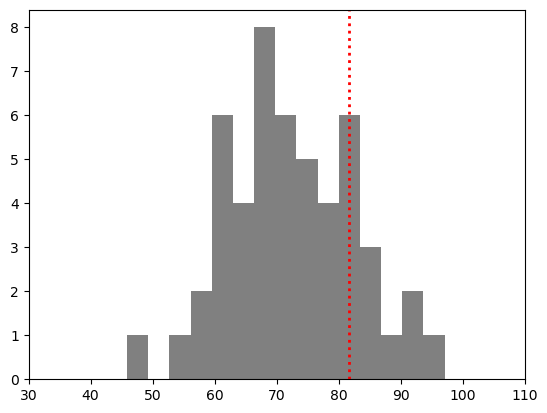

In [11]:
import matplotlib.pyplot as plt
plt.hist(chisq, 15, color='gray')
plt.axvline(x=81.7, color='r', ls=':', linewidth=2)
plt.xlim(30,110)
#plt.show()
plt.savefig("Chisq_PARTIALtest_oct25.pdf")

In [65]:
diffs = []
for i in range(50):
    if i!=26:
        s8diff = extract_diff_s8(i)
        diffs.append(s8diff)
print(diffs)

Removed no burn in
0
Removed no burn in
Removed no burn in
1
Removed no burn in
Removed no burn in
2
Removed no burn in
Removed no burn in
3
Removed no burn in
Removed no burn in
4
Removed no burn in
Removed no burn in
5
Removed no burn in
Removed no burn in
6
Removed no burn in
Removed no burn in
7
Removed no burn in
Removed no burn in
8
Removed no burn in
Removed no burn in
9
Removed no burn in
Removed no burn in
10
Removed no burn in
Removed no burn in
11
Removed no burn in
Removed no burn in
12
Removed no burn in
Removed no burn in
13
Removed no burn in
Removed no burn in
14
Removed no burn in
Removed no burn in
15
Removed no burn in
Removed no burn in
16
Removed no burn in
Removed no burn in
17
Removed no burn in
Removed no burn in
18
Removed no burn in
Removed no burn in
19
Removed no burn in
Removed no burn in
20
Removed no burn in
Removed no burn in
21
Removed no burn in
Removed no burn in
22
Removed no burn in
Removed no burn in
23
Removed no burn in
Removed no burn in
24
Remo

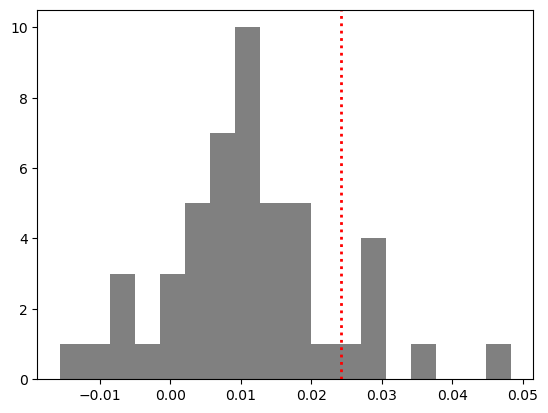

In [74]:
plt.hist(diffs, 18, color='gray')
plt.axvline(x=0.02422, color='r', ls=':', linewidth=2)
#plt.show()
plt.savefig("s8_diff_fig.pdf")

In [76]:
j=0
for i in range(len(diffs)):
    if diffs[i]> 0.02422:
        j+=1
j=j/len(diffs)
print(j)

0.14285714285714285


In [ ]:
#Comparison with bootstrap/jackknife w/randomization:

my_cov = fits.open('../data/covariance/xip_xim_map3_covariance_MORECUT_24Oct24.fits')

def chisq_auto_only(cov, zbin):
    
    indices = [0,10,16,19]
    sm = 400+indices[zbin-1]*4
    lg = 400+(indices[zbin-1]+1)*4
    autocov = my_cov[1].data[sm:lg,:][:,sm:lg]
    
#First we load the auto-iii-only part of our cov
